In [1]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from synthesizer import Galaxy
from synthesizer.parametric import SFH, Stars, ZDist
from synthesizer.grid import Grid
from synthpop.distribution_functions import Schechter
from synthpop.galaxy_population import GalaxyPopulation
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc, dimensionless


In [2]:

# Define the galaxy stellar mass function (GSMF) using a Schechter function
x_star = 10**10.745 * Msun     
phi_star = 10**(-2.437) * Mpc**-3  
alpha = -1.465
gsmf = Schechter(x_star=x_star, alpha=alpha, phi_star=phi_star)

print(gsmf)

----------
SUMMARY OF DISTRIBUTION FUNCTION
Name: Schechter
x_star: 55590425727.04026
phi_star: 0.0036559479161312504 Mpc**(-3)
alpha: -1.465
----------



In [ ]:
# load grid
grid = Grid("test_grid")

## define the star formation and metal enrichment history

In [4]:

# Define a delta function for metallicity
metal_dist_function = ZDist.DeltaConstant

metal_dist_parameters = {
    "log10metallicity": -2.5
}


age_of_universe = unyt_quantity(cosmo.age(0).value, str(cosmo.age(0).unit))

sfh_function = SFH.LogNormal

def peak_age_function(mass, age_of_Universe=1.37E10 * yr):

    value = (mass/(1E9*Msun))**2.5 * 1E9 + np.random.normal(0, 1e9)

    return np.min((value, age_of_Universe.to('yr').value)) * yr

def tau_function(mass):
    return np.clip(np.random.normal(0.6, 0.1) * dimensionless, 0.1, 1.0)

sfh_parameters = {
    "tau": 0.6 * dimensionless,
    "peak_age": 1e10 * yr,
    "max_age": age_of_universe
}

# sfh_parameters = {
#     "tau": tau_function,
#     "peak_age": peak_age_function,
#     "max_age": age_of_universe
# }


sfh_function = SFH.Constant

sfh_parameters = {
    "max_age": 10000 * Myr
}


In [5]:
# Define the volume of the galaxy population
volume = 1E4 * Mpc**3

# Define the star formation and metallicity histories for the galaxies in the population


# Instantiate the galaxy population
galpop = GalaxyPopulation(
    galaxy_stellar_mass_function=gsmf, 
    minimum_stellar_mass=1E9*Msun, 
    maximum_stellar_mass=1E11*Msun, 
    volume=volume,
    sfh_function=sfh_function,
    sfh_parameters=sfh_parameters,
    metal_dist_function=metal_dist_function,
    metal_dist_parameters=metal_dist_parameters,
    grid=grid,
    cosmology=cosmo,
    redshift=0.0,
    random_seed=42)


print(galpop)




/Users/sw376/Dropbox/Research/projects/synthpop/venv/lib/python3.10/site-packages/unyt/array.py:1900: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 371
Volume: 1.00e+04 Mpc**3
Redshift: 0.0
Total surviving stellar mass density: 2.77e+08 Msun/Mpc**3
Range of surviving stellar masses: 1.01e+09 - 8.84e+10
Age of the universe at z=0.0: 1.38e+04 Myr
----------



/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:285: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


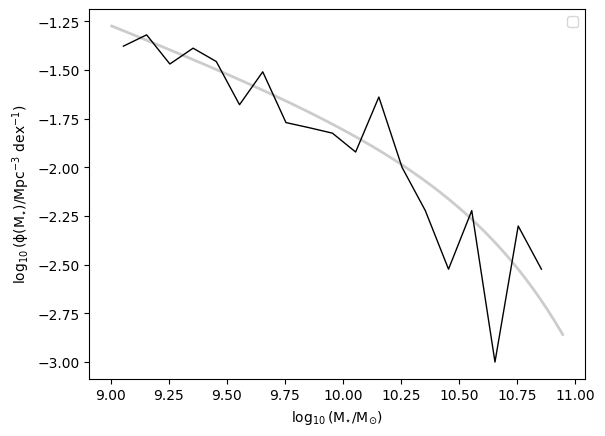

In [6]:


galpop.plot_stellar_mass_function()




/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:312: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


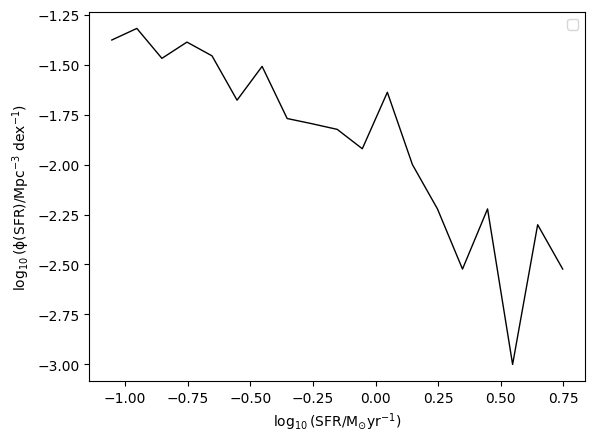

In [7]:

galpop.plot_star_formation_rate_distribution_function()



/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:357: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


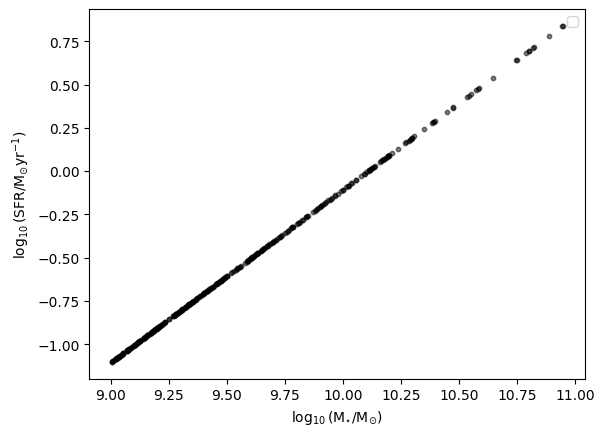

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


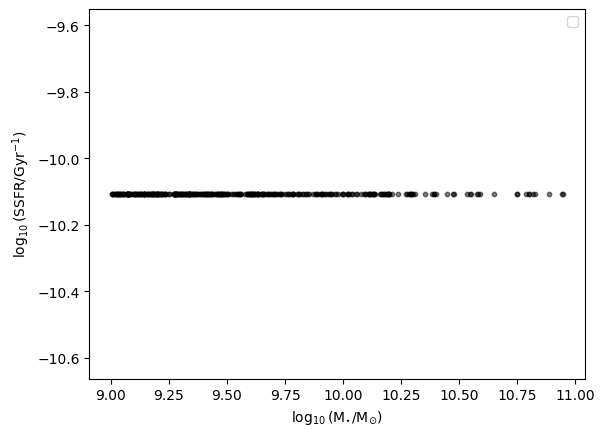

In [8]:
galpop.plot_sfr_vs_stellar_mass()
galpop.plot_ssfr_vs_stellar_mass()

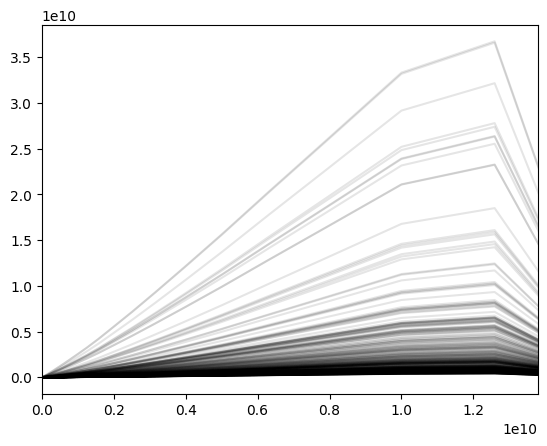

In [9]:
galpop.plot_sfhs(N='all')

|====== EmissionModel: incident ======|
|-------------------------------------|
|  INCIDENT (stellar)                 |
|-------------------------------------|
|Extraction model:                    |
|  Grid: test_grid                    |
|  Extract key: incident              |
|  Use velocity shift: False          |
|  Save emission: True                |
|=====================================|
Plotting spectra for 10 out of 371 galaxies in the population.


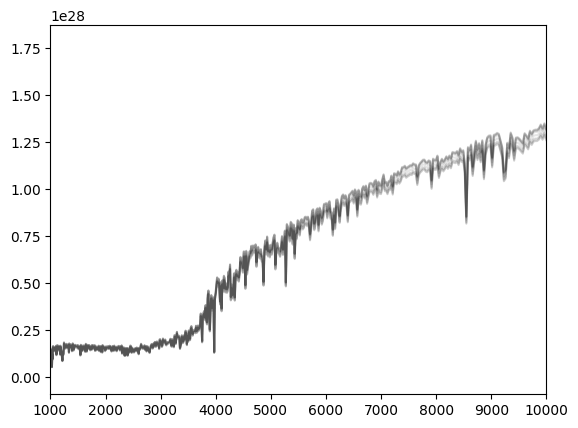

In [10]:
from synthesizer.emission_models import IncidentEmission

incident = IncidentEmission(grid=grid)
print(incident)


galpop.generate_spectra(incident)

galpop.plot_spectra('incident')


/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:340: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


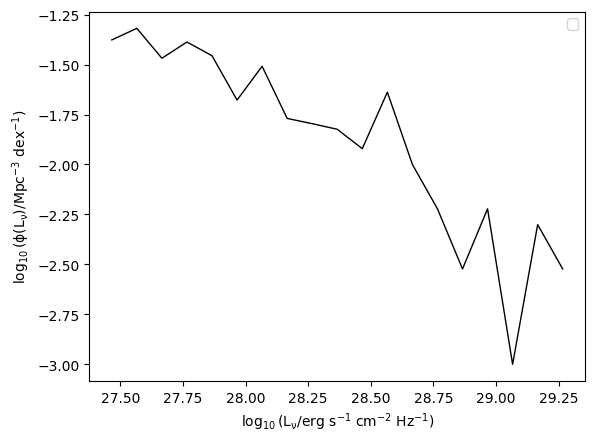

In [11]:

from synthesizer.filters import UVJ

# Get a UVJ filter collection
uvj = UVJ(new_lam=grid.lam)


galpop.generate_photometry('incident', uvj)


galpop.plot_luminosity_function('incident', 'U')

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:391: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


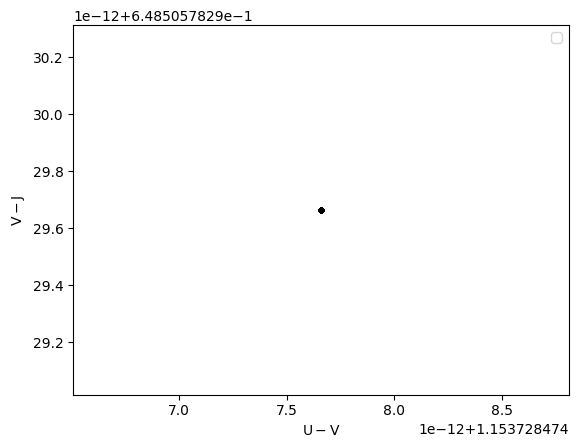

In [12]:
galpop.plot_color_color_diagram('incident', ['U','V', 'J'])

## Project galaxy population to earlier time

In [14]:
galpop_z1 = galpop.project_to_earlier_epoch(redshift=3.0)

print(galpop)
print(galpop_z1)

11643.13146468227 Myr
----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 371
Volume: 1.00e+04 Mpc**3
Redshift: 0.0
Total surviving stellar mass density: 2.77e+08 Msun/Mpc**3
Range of surviving stellar masses: 1.01e+09 - 8.84e+10
Age of the universe at z=0.0: 1.38e+04 Myr
----------

----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 371
Volume: 1.00e+04 Mpc**3
Redshift: 3.0
Total surviving stellar mass density: 4.28e+07 Msun/Mpc**3
Range of surviving stellar masses: 1.56e+08 - 1.36e+10
Age of the universe at z=3.0: 2.14e+03 Myr
----------



In [ ]:

galpop.plot_stellar_mass_function()
print(galpop.age_of_the_universe)
galpop_z1.plot_stellar_mass_function()
print(galpop_z1.age_of_the_universe)
